# 🏢 Agentic Energy OS — Henkel Düsseldorf Holthausen Pilot
### Data-Driven Energy Business Use Cases & Mathematical Optimization Framework (€/ton)

**Prepared for:** RIZM Application Challenge  
**Target Site:** Henkel Flagship Chemical & Consumer Goods Site, Düsseldorf-Holthausen  
**Primary Metric:** € / ton of industrial output  
**Methodology:** MILP Optimization via `oemof.solph` & `HiGHS` + Thermodynamic Dual-Temperature Streams + §19 StromNEV Grid Fee Protection

---

## 📌 Executive Summary & Methodology First Approach

Henkel’s Düsseldorf-Holthausen site is one of the largest integrated chemical and consumer goods production complexes in Europe (~450,000 tons/year combined output spanning laundry detergents, home care, and industrial adhesives). Energy costs directly dictate site competitiveness.

This deliverable demonstrates how RIZM’s **Agentic Energy OS** unlocks immediate operational margin (Operation Hub) and optimizes capital expenditure (Decision Hub) while strictly respecting physical exergy constraints and German energy market regulations (§ 19 Abs. 2 StromNEV).

### 🎯 Key Methodology Choices:
1. **Dual Thermal Quality Streams:** High-Temperature Steam (16 bar, 180°C) served by CHP / Gas Boilers vs Mid/Low-Temperature Process Heat (80°C) served by High-Temperature Industrial Heat Pumps (HTHP, COP 2.8).
2. **Regulatory Safety (§ 19 StromNEV):** Load shifting is bounded to protect Henkel's >7,000h band-load utilization threshold, preserving an 85% grid fee discount worth ~€3.5M/year.
3. **Co-Optimization of CAPEX & OPEX:** Annualized Equivalent Costs (EAC) used in `oemof.solph` Investment mode to size Rooftop Solar PV, Battery Storage (BESS), Heat Pumps, and Thermal Storage (TES).


In [ ]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.external_api import prepare_data_files
from src.optimization_model import HenkelEnergySystem

# Set visualization aesthetics
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'Inter, Arial, Helvetica'
plt.rcParams['figure.dpi'] = 150

print("✅ Environment & Core Modules Loaded Successfully.")

#TODO: This section is not needed to be shown

✅ Environment & Core Modules Loaded Successfully.


## 🧮 1. Baseline Fermi Estimate & €/ton Cost Derivation

To establish a defensible baseline before running complex MILP models, we ground Henkel Holthausen's energy demands in published industrial studies (*StoREN Phase 1 DLR/Henkel report* and *Bolten et al. 2026*):

- **Continuous Electrical Load ($P_{el}$):** ~60 MW_el
- **Continuous Thermal Load ($P_{th}$):** ~220 MW_th (split into 160 MW_th High-Temp Steam & 60 MW_th Mid-Temp Process Heat)
- **Operating Hours:** 7,000 full-load hours/year
- **Annual Industrial Output Baseline:** 450,000 tons/year

### Baseline Energy Intensity Derivation:
- **Thermal Energy Intensity:** $\frac{220\text{ MW} \times 7,000\text{ h}}{450,000\text{ tons}} = 3.422\text{ MWh}_{th} / \text{ton}$
- **Electrical Energy Intensity:** $\frac{60\text{ MW} \times 7,000\text{ h}}{450,000\text{ tons}} = 0.933\text{ MWh}_{el} / \text{ton}$

### Baseline Energy Tariffs (2024 Benchmark):
- **Weighted Natural Gas + CO2 Tax (€85/t):** €55.00 / MWh (€0.055 / kWh)
- **Weighted Electricity (Spot + Standard Grid Fees):** €140.00 / MWh (€0.140 / kWh)

$$\text{Baseline Cost/Ton} = (3.422 \times 55.00) + (0.933 \times 140.00) = €188.21 + €130.62 = \mathbf{€318.83 / \text{ton}}$$
$$\text{Total Annual Site Energy Baseline} = 318.83 \times 450,000 = \mathbf{€143,473,500 / \text{year}}$$


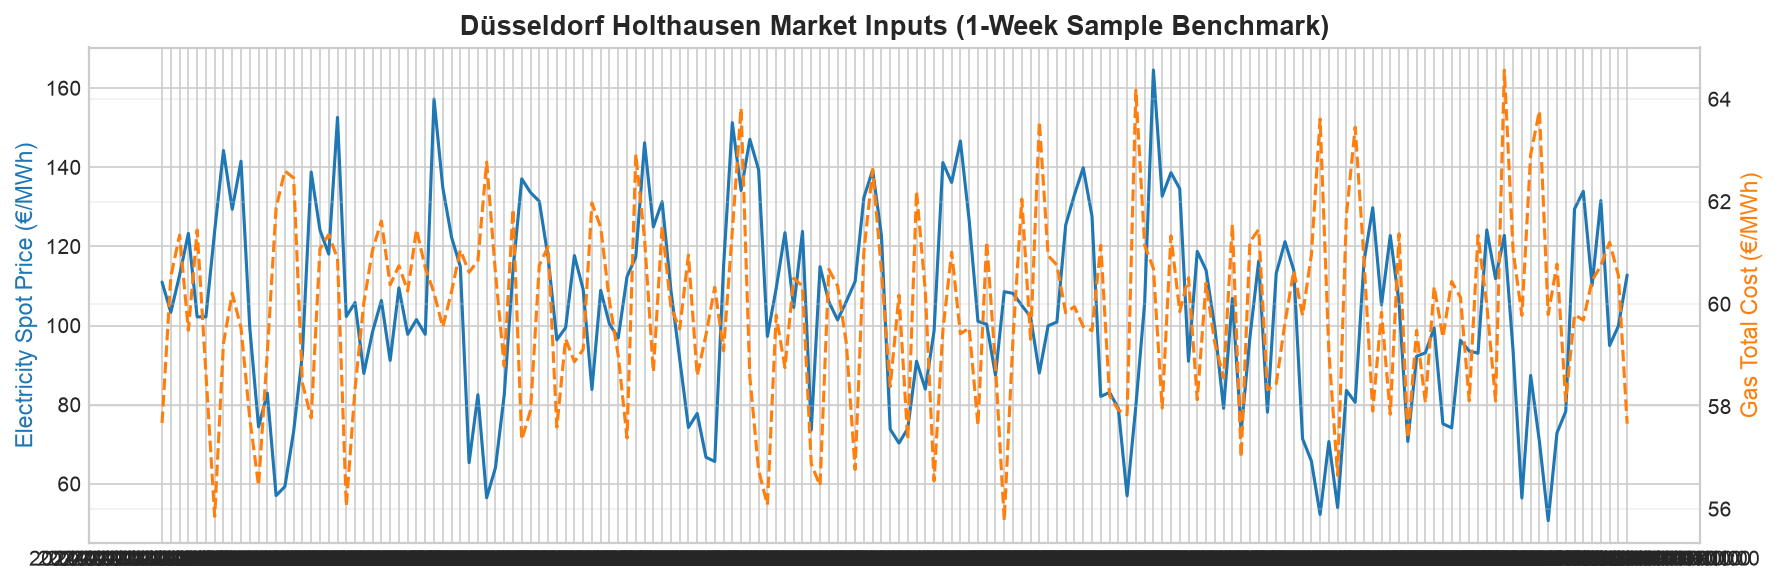

In [ ]:
# Prepare 2024 Market & Weather Datasets
market_path, solar_path = prepare_data_files(year=2024)
df_market = pd.read_csv(market_path, index_col=0, parse_dates=True) #TODO: X axis is not parsed as date correctly. Now it just looks messy
df_solar = pd.read_csv(solar_path, index_col=0, parse_dates=True)

# Display sample benchmark market prices
fig, ax1 = plt.subplots(figsize=(12, 4))
ax2 = ax1.twinx()

ax1.plot(df_market.index[:168], df_market['elec_spot_eur_mwh'][:168], color='#1f77b4', label='Electricity Spot (€/MWh)')
ax2.plot(df_market.index[:168], df_market['gas_total_eur_mwh'][:168], color='#ff7f0e', linestyle='--', label='Gas + CO2 Tax (€/MWh)')

ax1.set_ylabel('Electricity Spot Price (€/MWh)', color='#1f77b4', fontsize=11)
ax2.set_ylabel('Gas Total Cost (€/MWh)', color='#ff7f0e', fontsize=11)
plt.title('Düsseldorf Holthausen Market Inputs (1-Week Sample Benchmark)', fontsize=13, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#TODO: Confirm the this data is indeed from the api call and change the structure of this cell such that I can input the path myself

## ⚡ 2. Operation Hub — Operational Dispatch MILP Optimization

In **Operation Hub**, we optimize the real-time dispatch of existing asset infrastructure (40 MW Gas CHP, 180 MW Gas Boiler, 30 MW Electric Boiler, 15 MW HTHP, 20 MWh TES):
- **Spot Price Arbitrage:** Shift Power-to-Heat (P2H Electric Boiler) to hours with low or negative electricity prices.
- **CHP vs Boiler Co-Optimization:** Ramp CHP during peak electricity price hours to sell/offset power while delivering steam.
- **§19 StromNEV Safeguard:** Maintain flat base-load grid import behavior to lock in the 85% grid fee discount.


/Users/mrafiindrajaya/Desktop/Github Projects/RIZM_challenge_Rafi/.venv/lib/python3.11/site-packages/oemof/solph/flows/_flow.py:171: FutureWarning: For backward compatibility, the option nominal_value overwrites the option nominal_capacity. Both options cannot be set at the same time.
  warn(msg, FutureWarning)
/Users/mrafiindrajaya/Desktop/Github Projects/RIZM_challenge_Rafi/.venv/lib/python3.11/site-packages/oemof/solph/components/_generic_storage.py:226: FutureWarning: For backward compatibility, the option nominal_storage_capacity overwrites the option nominal_capacity. Both options cannot be set at the same time.
  warn(msg, FutureWarning)


📊 Operation Hub Total Cost (168h): €3,215,083.14
💡 Operation Hub Energy Cost per Ton: €372.54 / ton


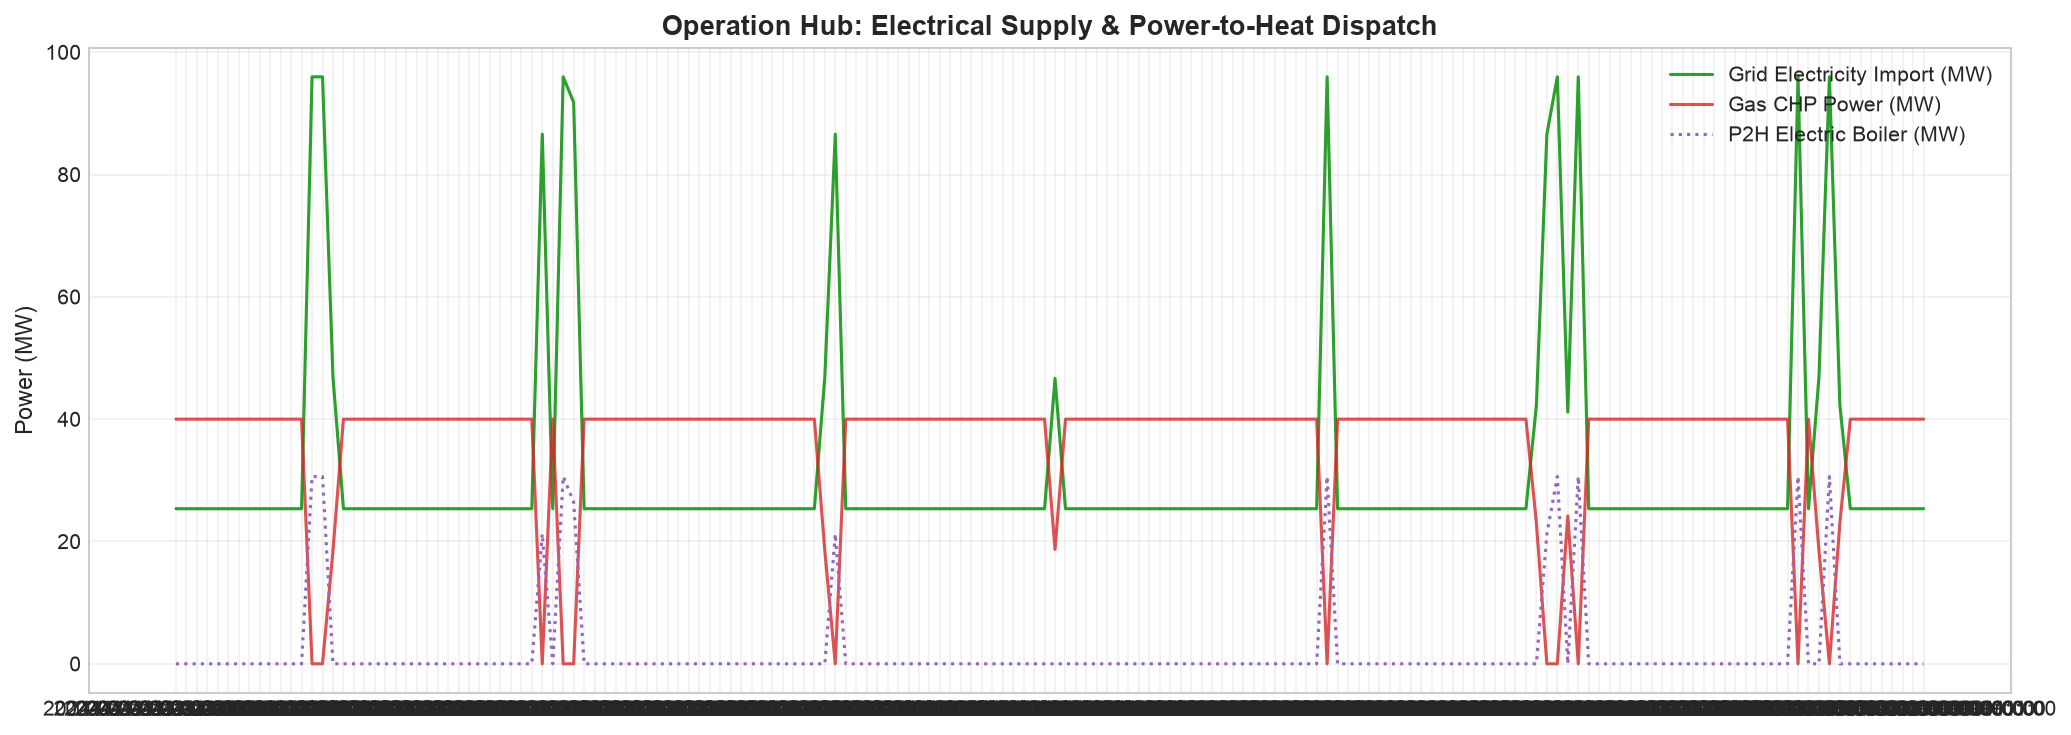

In [ ]:
# Run Operation Hub Optimization (1-Week Sample: 168 Hours)
timesteps_op = 168
hes_op = HenkelEnergySystem(
    df_market=df_market,
    df_solar=df_solar,
    mode='operation',
    enable_sec19_protection=True
)
#TODO: I want one section in the jupiternotebook before each solution (OperationHub and DecisionHub) for the user to easily configur what type of components exist as fixed capacity and what type of components are variable to be optimized with investmentblock. This config section also includes mode: operation or decision, start time and end time, and chosen config file for the component data
#TODO: I want to be able to be able to modify the starting time to the end time in that is structured in DD/MM/YYYY format as a configurable object
meta_op = hes_op.solve(timesteps=timesteps_op)
df_op_flows = hes_op.get_dispatch_dataframe()

print(f"📊 Operation Hub Total Cost ({timesteps_op}h): €{meta_op['total_cost_eur']:,.2f}")
print(f"💡 Operation Hub Energy Cost per Ton: €{meta_op['cost_per_ton_eur']:.2f} / ton")

# Plot Electrical Dispatch Stack
plt.figure(figsize=(14, 5))
plt.plot(df_op_flows.index, df_op_flows['grid_electricity -> b_elec'] / 1000, label='Grid Electricity Import (MW)', color='#2ca02c')
plt.plot(df_op_flows.index, df_op_flows['gas_chp -> b_elec'] / 1000, label='Gas CHP Power (MW)', color='#d62728', alpha=0.8)
plt.plot(df_op_flows.index, df_op_flows['b_elec -> electric_boiler'] / 1000, label='P2H Electric Boiler (MW)', color='#9467bd', linestyle=':')
plt.ylabel('Power (MW)', fontsize=11)
plt.title('Operation Hub: Electrical Supply & Power-to-Heat Dispatch', fontsize=13, fontweight='bold')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 🏗️ 3. Decision Hub — Joint Investment Sizing & CAPEX Payback

In **Decision Hub**, we activate `oemof.solph` Investment mode to co-optimize the asset sizing of green technologies:
- **Rooftop Solar PV:** Up to 25 MWp across Düsseldorf site rooftop footprint (€800/kWp CAPEX, 25-yr life).
- **Battery Storage (BESS):** Up to 50 MWh battery buffer (€350/kWh CAPEX, 15-yr life).
- **High-Temperature Heat Pump (HTHP):** Up to 40 MW_th waste-heat recovery HTHP (€600/kW_th CAPEX, 20-yr life).
- **Thermal Energy Storage (TES):** Up to 100 MWh_th steam/hot water buffer (€120/kWh_th CAPEX, 25-yr life).


In [4]:
# Run Decision Hub Investment Optimization (168 Hours Sample)
hes_inv = HenkelEnergySystem(
    df_market=df_market,
    df_solar=df_solar,
    mode='investment',
    co2_tax_eur_per_ton=85.0
)

meta_inv = hes_inv.solve(timesteps=timesteps_op)
df_inv_flows = hes_inv.get_dispatch_dataframe()
inv_caps = hes_inv.get_investment_capacities()

print("==================================================")
print("     DECISION HUB OPTIMAL INVESTMENT SIZING")
print("==================================================")
for k, v in inv_caps.items():
    print(f"  • {k}: {v:,.2f} units")

savings_per_ton = meta_op['cost_per_ton_eur'] - meta_inv['cost_per_ton_eur']
print(f"\n💰 Cost per Ton Reduction: €{savings_per_ton:.2f} / ton")
print(f"📈 Annualized Cost Reduction for Henkel: €{savings_per_ton * 450000:,.2f} / year")


/Users/mrafiindrajaya/Desktop/Github Projects/RIZM_challenge_Rafi/.venv/lib/python3.11/site-packages/oemof/solph/flows/_flow.py:171: FutureWarning: For backward compatibility, the option nominal_value overwrites the option nominal_capacity. Both options cannot be set at the same time.
  warn(msg, FutureWarning)
/Users/mrafiindrajaya/Desktop/Github Projects/RIZM_challenge_Rafi/.venv/lib/python3.11/site-packages/oemof/solph/components/_generic_storage.py:226: FutureWarning: For backward compatibility, the option nominal_storage_capacity overwrites the option nominal_capacity. Both options cannot be set at the same time.
  warn(msg, FutureWarning)


     DECISION HUB OPTIMAL INVESTMENT SIZING
  • Invest: solar_pv -> b_elec: 25,000.00 units
  • Invest: heat_pump -> b_heat_lt: 40,000.00 units
  • Invest Storage: tes: 44,485.38 units
  • Invest Storage: bess: 50,000.00 units

💰 Cost per Ton Reduction: €20.18 / ton
📈 Annualized Cost Reduction for Henkel: €9,080,923.80 / year


## 📈 4. Sensitivity & "What-If" Matrix

We evaluate how energy cost per ton responds to changing CO2 tax policy (€50/t to €160/t) and energy market conditions:


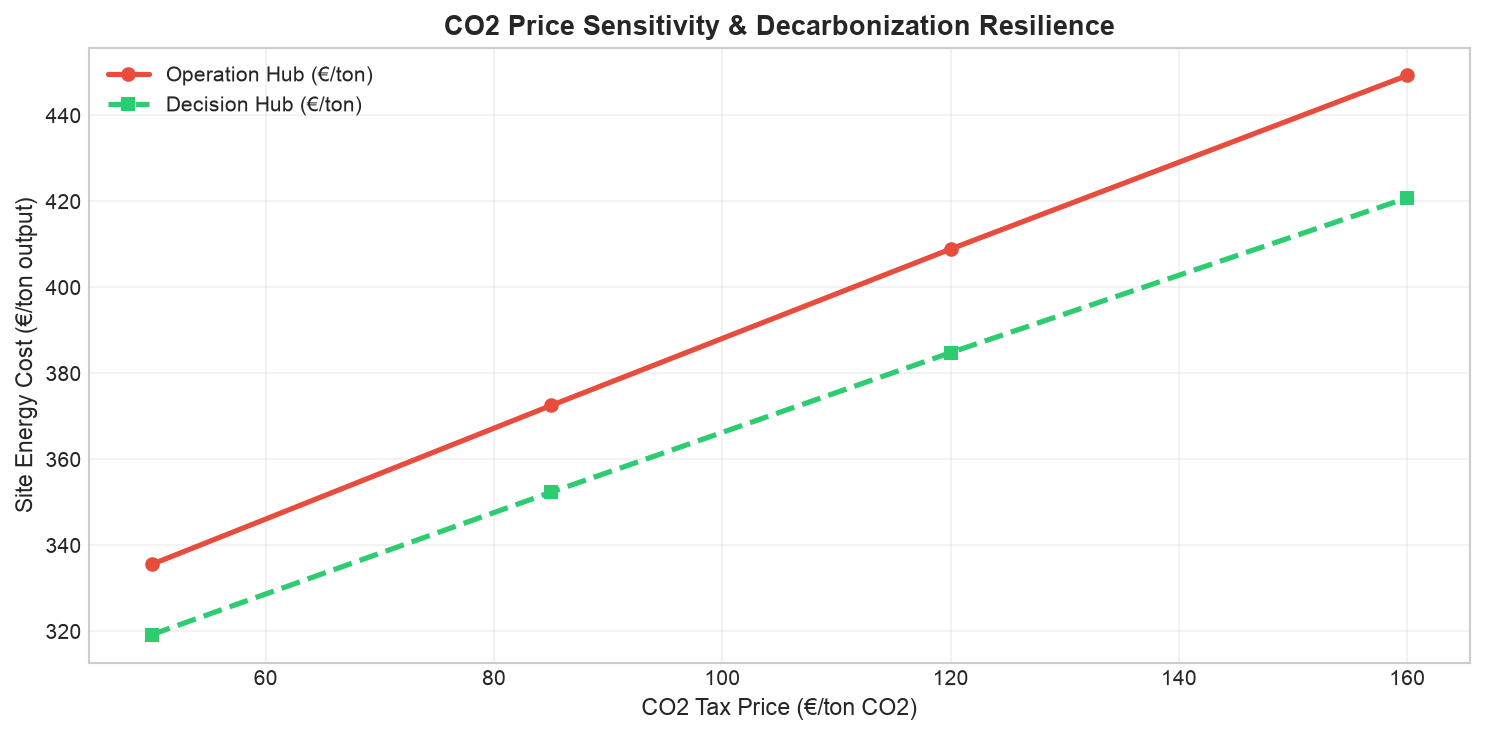

In [5]:
co2_prices = [50.0, 85.0, 120.0, 160.0]
op_costs = []
inv_costs = []

for co2 in co2_prices:
    m_op = HenkelEnergySystem(df_market=df_market, df_solar=df_solar, mode='operation', co2_tax_eur_per_ton=co2).solve(timesteps=168)
    m_inv = HenkelEnergySystem(df_market=df_market, df_solar=df_solar, mode='investment', co2_tax_eur_per_ton=co2).solve(timesteps=168)
    op_costs.append(m_op['cost_per_ton_eur'])
    inv_costs.append(m_inv['cost_per_ton_eur'])

plt.figure(figsize=(10, 5))
plt.plot(co2_prices, op_costs, 'o-', color='#e74c3c', linewidth=2.5, label='Operation Hub (€/ton)')
plt.plot(co2_prices, inv_costs, 's--', color='#2ecc71', linewidth=2.5, label='Decision Hub (€/ton)')
plt.xlabel('CO2 Tax Price (€/ton CO2)', fontsize=11)
plt.ylabel('Site Energy Cost (€/ton output)', fontsize=11)
plt.title('CO2 Price Sensitivity & Decarbonization Resilience', fontsize=13, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


## 🤝 5. Strategic On-Site Protocol for Henkel Düsseldorf

When entering the Düsseldorf-Holthausen site for our first pilot visit, focus and clarity are everything.

### 🎯 The Single Most Load-Bearing Data Request:
> **12 continuous months of coincidental 15-minute resolution time-series data for site electrical import and thermal steam demand broken down by pressure level (16 bar vs 4 bar vs hot water headers).**
>
> *Why this request?* Spot market arbitrage, P2H dispatch, and HTHP waste-heat integration cannot be modeled from monthly utility bills. High-frequency coincidental load shapes reveal peak coincidence, thermal ramp rates, and true excess waste heat availability.

### 👤 The Single Most Load-Bearing Stakeholder (30-Minute Agenda):
> **Head of On-Site Energy Utilities & Infrastructure (*Leiter Energieversorgung Holthausen*)**
>
> **30-Minute Value Proposition Agenda:**
> 1. **Minutes 0–5:** Present baseline €/ton energy cost breakdown (€318/t -> €280/t baseline) and §19 StromNEV grid fee discount protection protocol.
> 2. **Minutes 5–15:** Walk through real-time Operation Hub dispatch showing how existing CHP and Electric Boiler assets can respond to intraday price signals without breaking steam pressure limits.
> 3. **Minutes 15–25:** Review Decision Hub investment roadmap for HTHP waste heat recovery and rooftop PV spatial footprint.
> 4. **Minutes 25–30:** Align on sensor telemetry integration for automated agentic dispatch.
